###1️⃣ Imports

In [ ]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Save/Load trained model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

###2️⃣ Load Dataset

In [ ]:
# Load dataset
df = pd.read_csv("engine_data.csv")

###3️⃣ Basic Exploration

In [ ]:
# Check shape
df.shape

(19535, 7)

In [ ]:
# Data types
df.dtypes

,0
Engine rpm,int64
Lub oil pressure,float64
Fuel pressure,float64
Coolant pressure,float64
lub oil temp,float64
Coolant temp,float64
Engine Condition,int64


In [ ]:
# DataFrame description
df.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [ ]:
# Verify that there are no null values
df.isnull().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0


In [ ]:
# Calculate value range
df.max() - df.min()

,0
Engine rpm,2178.000000
Lub oil pressure,7.262181
Fuel pressure,21.135138
Coolant pressure,7.476022
lub oil temp,18.258822
Coolant temp,133.854587
Engine Condition,1.000000


In [ ]:
# Correlation
df.corr()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
Engine rpm,1.000000,0.025046,-0.001571,-0.024979,0.052134,0.029560,-0.268201
Lub oil pressure,0.025046,1.000000,0.043790,-0.009357,-0.008031,-0.060906,0.060904
Fuel pressure,-0.001571,0.043790,1.000000,0.033264,-0.025338,-0.042986,0.116259
Coolant pressure,-0.024979,-0.009357,0.033264,1.000000,-0.020761,0.033451,-0.024054
lub oil temp,0.052134,-0.008031,-0.025338,-0.020761,1.000000,0.072914,-0.093635
Coolant temp,0.029560,-0.060906,-0.042986,0.033451,0.072914,1.000000,-0.046326
Engine Condition,-0.268201,0.060904,0.116259,-0.024054,-0.093635,-0.046326,1.000000


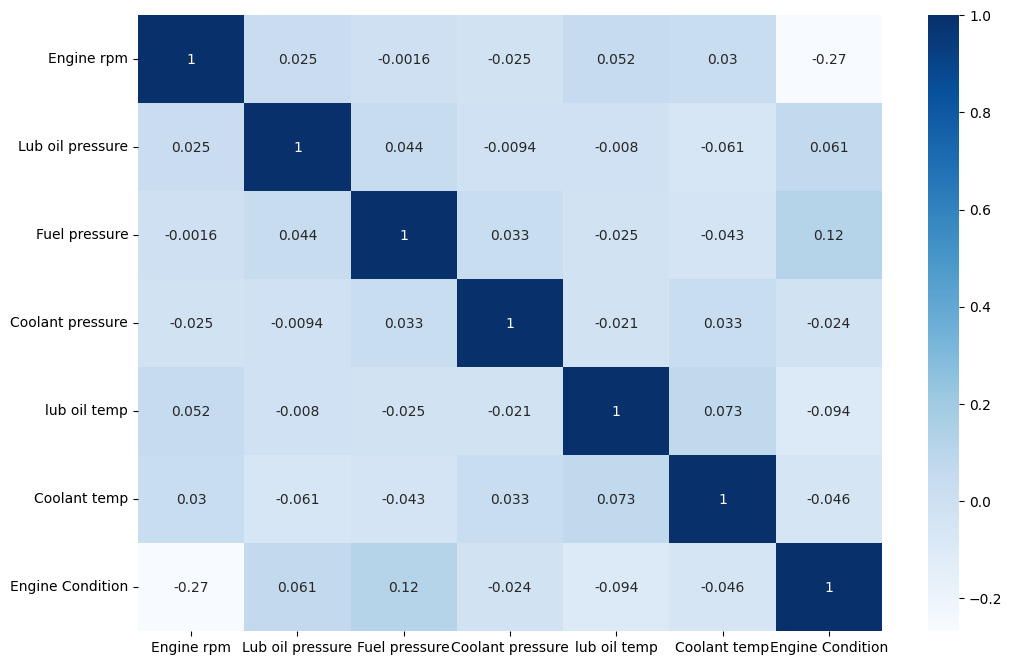

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
plt.show()

In [ ]:
# Class distribution
df["Engine Condition"].value_counts()

,count
Engine Condition,
1,12317
0,7218


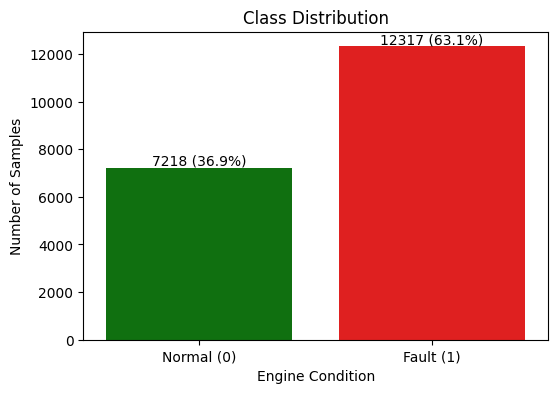

In [ ]:
plt.figure(figsize=(6,4))

# Create the count plot for the target variable
ax = sns.countplot(
    x="Engine Condition",     # Feature shown on the x-axis
    data=df,                  # Dataset
    order=[0,1],              # Ensure classes appear in logical order
    palette=["green", "red"]  # Custom colors for each class
)

# Add axis labels and plot title
plt.xticks([0,1], ["Normal (0)", "Fault (1)"])
plt.xlabel("Engine Condition")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

# Get the total number of samples in the dataset
total = len(df)

# Add labels with count and percentage above each bar
for p in ax.patches:
    # Get the height of the bar (number of samples in that class)
    count = int(p.get_height())
    # Calculate percentage relative to the total dataset
    percentage = 100 * count / total
    # Add annotation above the bar
    ax.annotate(
        f"{count} ({percentage:.1f}%)",
        (p.get_x() + p.get_width()/2, count), # Position at the center top of the bar
        ha="center",
        va="bottom"
    )

plt.show()

We define:

* 1 = Defective engine
* 0 = Healthy engine

###4️⃣ Train-Test Split

In [ ]:
# Separate features and target
X = df.drop("Engine Condition", axis=1)
y = df["Engine Condition"]

# Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**stratify=y**:
* the split is forced to maintain the proportions
| Dataset | Normal | Faulty  |
| ------- | ---- | ---- |
| Train   | ~37% | ~63% |
| Test    | ~37% | ~63% |


###5️⃣ Feature Scaling (for LR and MLP)
(Random Forest does NOT need scaling)

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###6️⃣ Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a classification model by computing common metrics
    and displaying the confusion matrix and classification report.
    """

    # Predict class labels for the test set
    y_pred = model.predict(X_test)

    # Predicted probabilities for the positive class (used for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Compute evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Print performance metrics
    print(f"\n{model_name} Performance")
    print("-" * 40)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

    # Print detailed classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, prec, rec, f1, roc

###7️⃣ Logistic Regression


Logistic Regression Performance
----------------------------------------
Accuracy : 0.6611
Precision: 0.6787
Recall   : 0.8782
F1-score : 0.7657
ROC-AUC  : 0.6918

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.29      0.39      1444
           1       0.68      0.88      0.77      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.58      0.58      3907
weighted avg       0.64      0.66      0.63      3907



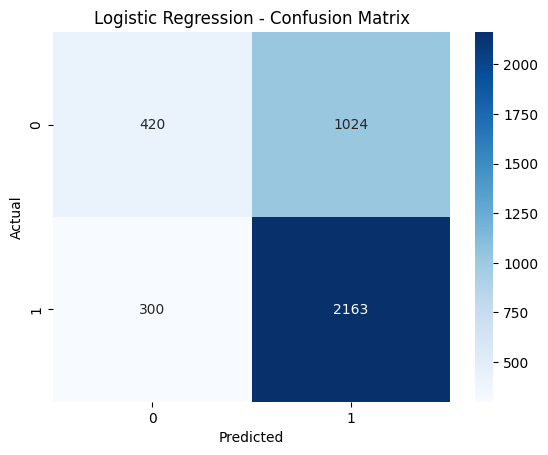

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

lr_metrics = evaluate_model(
    lr_model,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

Slight regularization tuning


Logistic Regression (Tuned) Performance
----------------------------------------
Accuracy : 0.6611
Precision: 0.6778
Recall   : 0.8814
F1-score : 0.7663
ROC-AUC  : 0.6918

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.29      0.38      1444
           1       0.68      0.88      0.77      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.58      0.57      3907
weighted avg       0.64      0.66      0.62      3907



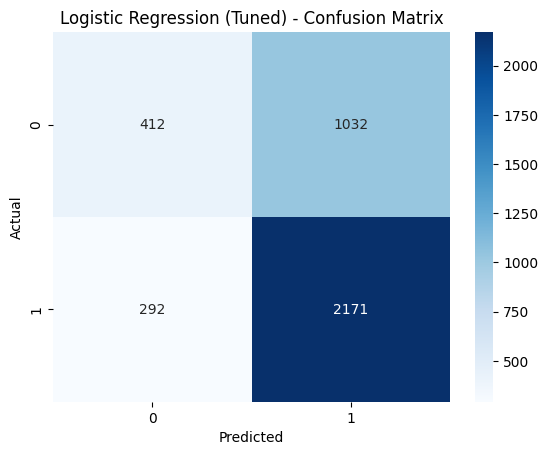

In [ ]:
lr_model_tuned = LogisticRegression(
    C=0.01,
    max_iter=2000
)

lr_model_tuned.fit(X_train_scaled, y_train)

lr_tuned_metrics = evaluate_model(
    lr_model_tuned,
    X_test_scaled,
    y_test,
    "Logistic Regression (Tuned)"
)

- If the solver finds the minimum before 1000 iterations, then:
  * 1000 iterations = 2000 iterations → same result (max_iter has no influence)

- The features have a low correlation with the target:
| Feature          | Correlation with Engine Condition |
| ---------------- | -------------------------------- |
| Engine rpm       | **-0.27**                        |
| Fuel pressure    | 0.11                             |
| lub oil temp     | -0.09                            |
| Lub oil pressure | 0.06                             |
| Coolant temp     | -0.04                            |
| Coolant pressure | -0.02                            |

- This indicates:
  * weak linear signal
  * Logistic Regression has little ability to separate classes

- With large datasets:
  * the model is stable
  * small variations in hyperparameters do not significantly change the result

###8️⃣ Random Forest


Random Forest Performance
----------------------------------------
Accuracy : 0.6453
Precision: 0.6887
Recall   : 0.7978
F1-score : 0.7393
ROC-AUC  : 0.6773

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.39      0.45      1444
           1       0.69      0.80      0.74      2463

    accuracy                           0.65      3907
   macro avg       0.61      0.59      0.59      3907
weighted avg       0.63      0.65      0.63      3907



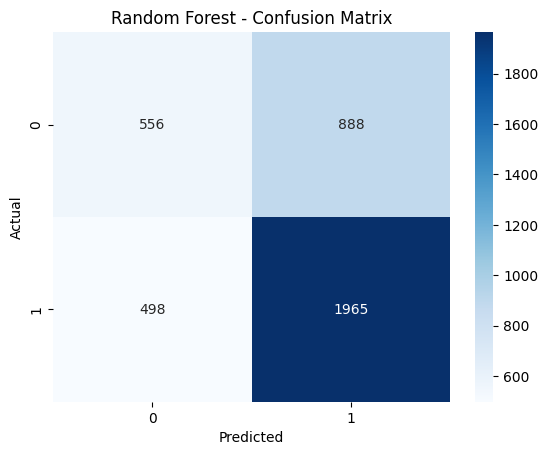

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_metrics = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

Tuned version
* 40 combinations × 5 folds = 200
* In addition, at the end, 1 additional model is retrained with the best hyperparameters using all of X_train.
  * Approximate actual total: 201 Random Forest training sessions.

In [ ]:
# @title RF hyperparameter search
# # Distribution of hyperparameters to sample from
# param_dist = {
#     "n_estimators": [200,300,400,500,700],  # Number of trees in the forest
#     "max_depth": [None,8,10,12,15,20],      # Maximum depth of each tree
#     "min_samples_split": [2,5,10,20],       # Minimum samples required to split a node
#     "min_samples_leaf": [1,2,4,6],          # Minimum samples required at a leaf node
#     "max_features": ["sqrt","log2",0.7],    # Number of features considered at each split
#     "bootstrap": [True, False]              # Whether bootstrap samples are used
# }

# # Base Random Forest model
# rf = RandomForestClassifier(
#     class_weight="balanced",  # Handle class imbalance
#     random_state=42,          # Ensure reproducibility
#     n_jobs=-1                 # Use all available CPU cores
# )

# # Randomized hyperparameter search
# rf_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist,  # Hyperparameter search space
#     n_iter=40,                       # Number of random combinations to try
#     scoring="roc_auc",               # Metric used to evaluate performance
#     cv=5,                            # 5-fold cross-validation
#     verbose=1,                       # Print training progress
#     n_jobs=-1                        # Parallelize across all cores
# )

# # Run the hyperparameter search
# # Total trainings = n_iter * cv = 40 * 5 = 200 Random Forest fits
# rf_search.fit(X_train, y_train)

# # Retrieve the best model found during the search
# best_rf = rf_search.best_estimator_

# # Evaluate the optimized model on the test set
# rf_metrics = evaluate_model(
#     best_rf,
#     X_test,
#     y_test,
#     "Random Forest Optimized"
# )

In [ ]:
# print(rf_search.best_params_)

The model is already trained with the best hyperparameters using all of X_train. So it can be saved, then loaded and evaluated directly

In [ ]:
# joblib.dump(best_rf, "best_random_forest.pkl")

In [ ]:
best_rf = joblib.load("best_random_forest.pkl")

In [ ]:
for k, v in best_rf.get_params().items():
    print(f"{k}: {v}")

bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 8
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 4
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 400
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False



Random Forest (Tuned) Performance
----------------------------------------
Accuracy : 0.6419
Precision: 0.7626
Recall   : 0.6273
F1-score : 0.6883
ROC-AUC  : 0.6991

Classification Report
              precision    recall  f1-score   support

           0       0.51      0.67      0.58      1444
           1       0.76      0.63      0.69      2463

    accuracy                           0.64      3907
   macro avg       0.64      0.65      0.63      3907
weighted avg       0.67      0.64      0.65      3907



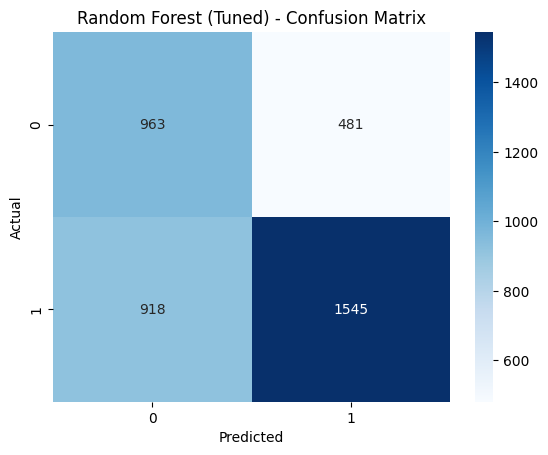

In [ ]:
rf_metrics = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Random Forest (Tuned)"
)

Tuning found:
```
max_depth=8
min_samples_leaf=4
```
This reduces **overfitting**.

Therefore:
* **precision increases** → the model becomes more conservative
* **recall decreases** → fewer positives are detected
* **ROC-AUC increases** → better overall separation between classes

###9️⃣ MLP Classifier


MLP Performance
----------------------------------------
Accuracy : 0.6527
Precision: 0.6853
Recall   : 0.8303
F1-score : 0.7509
ROC-AUC  : 0.6662

Classification Report
              precision    recall  f1-score   support

           0       0.55      0.35      0.43      1444
           1       0.69      0.83      0.75      2463

    accuracy                           0.65      3907
   macro avg       0.62      0.59      0.59      3907
weighted avg       0.63      0.65      0.63      3907



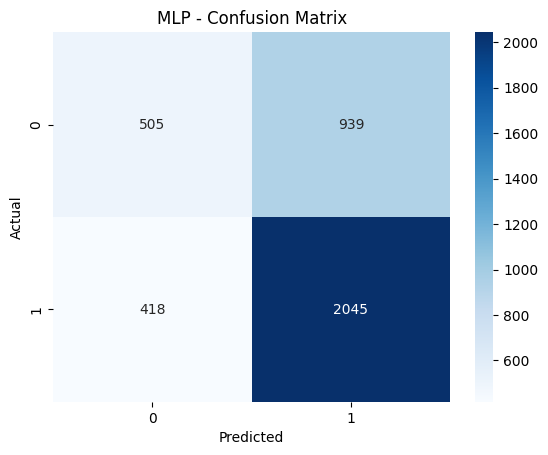

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

mlp_metrics = evaluate_model(
    mlp_model,
    X_test_scaled,
    y_test,
    "MLP"
)

Tuned version


MLP (Tuned) Performance
----------------------------------------
Accuracy : 0.6609
Precision: 0.6830
Recall   : 0.8624
F1-score : 0.7622
ROC-AUC  : 0.6961

Classification Report
              precision    recall  f1-score   support

           0       0.57      0.32      0.41      1444
           1       0.68      0.86      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.59      0.59      3907
weighted avg       0.64      0.66      0.63      3907



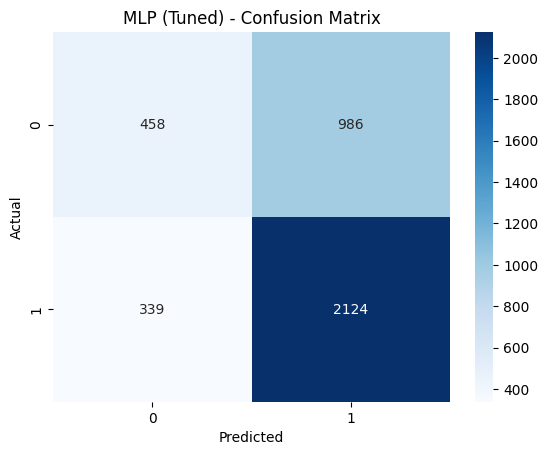

In [ ]:
mlp_model_tuned = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    alpha=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

mlp_model_tuned.fit(X_train_scaled, y_train)

mlp_tuned_metrics = evaluate_model(
    mlp_model_tuned,
    X_test_scaled,
    y_test,
    "MLP (Tuned)"
)

There are two important reasons behind these results:

**1. Low correlations with the target variable**

In the correlation matrix, the strongest correlation is:
* Engine rpm vs Engine Condition ≈ -0.27

This is relatively weak, which means that:
* no single variable adequately explains the condition of the engine
* the model needs interactions between variables

That is why non-linear models such as Random Forest and MLP work better than Logistic Regression.

**2. Slight imbalance of classes**

This causes the models to:
* have high recall for class 1
* have low recall for class 0

Because the model learns more patterns from the majority class.


###🔟 ROC Curves Comparison
(Base models)

<Figure size 640x480 with 0 Axes>

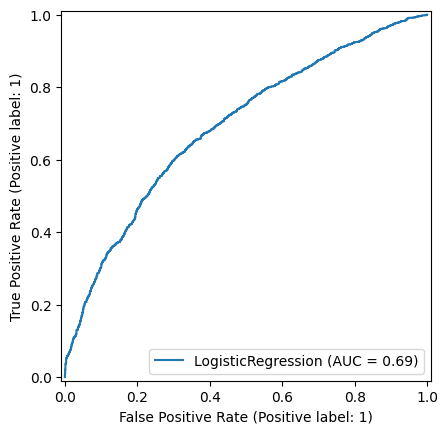

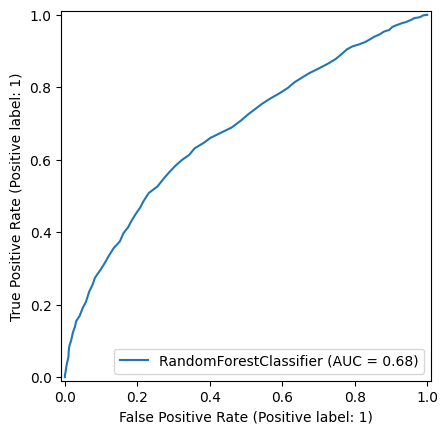

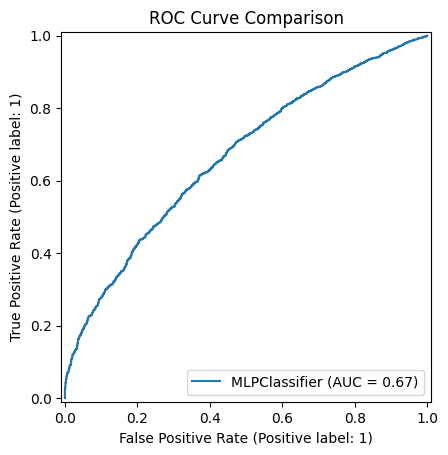

In [ ]:
plt.figure()

for model, X_data, name in [
    (lr_model, X_test_scaled, "Logistic Regression"),
    (rf_model, X_test, "Random Forest"),
    (mlp_model, X_test_scaled, "MLP")
]:
    RocCurveDisplay.from_estimator(model, X_data, y_test)

plt.title("ROC Curve Comparison")
plt.show()

###🔎 Conclusion

The results suggest that the predictive signal in the dataset is relatively weak, as reflected by the low correlations between features and the target variable. Consequently, both Random Forest and MLP models achieve moderate performance, capturing some non-linear relationships but still facing limitations due to the restricted feature set.

####**Interesting insight**

| Model              | Accuracy  | ROC-AUC   |
| ------------------- | --------- | --------- |
| Logistic Regression | **0.661** | 0.692     |
| MLP (Tuned)           | 0.661     | **0.696** |
| Random Forest (Tuned) | 0.642     | **0.699** |

This suggests that:
* The dataset is relatively simple
* Complex models do not offer much advantage

Interestingly, the relatively simple Logistic Regression model performs similarly to more complex models, suggesting that increasing model complexity does not significantly improve predictive performance for this dataset. This indicates that the main limitation is not model complexity but the limited predictive information contained in the available features.